In [1]:
#滙入pandas函式庫
import pandas as pd
#1-1 載入資料集
df = pd.read_csv("./titanic_data.csv")
#顯示資料集的形狀
print(df.shape)

(1309, 11)


In [2]:
#1-2 探索資料
# 查看前5筆記錄
print(df.head())
#將前5筆記錄儲存成html格式的檔案
df.head().to_html("example1_1.html") 

   pclass  survived                                             name     sex  \
0       1         1                    Allen  Miss. Elisabeth Walton  female   
1       1         1                   Allison  Master. Hudson Trevor    male   
2       1         0                     Allison  Miss. Helen Loraine  female   
3       1         0             Allison  Mr. Hudson Joshua Creighton    male   
4       1         0  Allison  Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked  
0  29.0000      0      0   24160  211.3375       B5        S  
1   0.9167      1      2  113781  151.5500  C22 C26        S  
2   2.0000      1      2  113781  151.5500  C22 C26        S  
3  30.0000      1      2  113781  151.5500  C22 C26        S  
4  25.0000      1      2  113781  151.5500  C22 C26        S  


In [3]:
#顯示資料集的描述資料
print(df.describe())
#將描述資料儲存成html格式的檔案
df.describe().to_html("example1_2.html")

            pclass     survived          age        sibsp        parch  \
count  1309.000000  1309.000000  1046.000000  1309.000000  1309.000000   
mean      2.294882     0.381971    29.881135     0.498854     0.385027   
std       0.837836     0.486055    14.413500     1.041658     0.865560   
min       1.000000     0.000000     0.166700     0.000000     0.000000   
25%       2.000000     0.000000    21.000000     0.000000     0.000000   
50%       3.000000     0.000000    28.000000     0.000000     0.000000   
75%       3.000000     1.000000    39.000000     1.000000     0.000000   
max       3.000000     1.000000    80.000000     8.000000     9.000000   

              fare  
count  1308.000000  
mean     33.295479  
std      51.758668  
min       0.000000  
25%       7.895800  
50%      14.454200  
75%      31.275000  
max     512.329200  


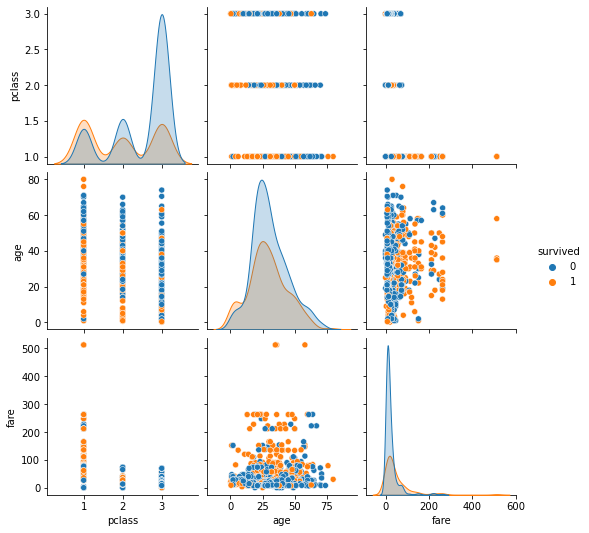

In [4]:
#1-3 資料視覺化
#滙入seaborn函數庫(套件)
import seaborn as sns 
#減少一些變數，顯示兩兩變變之間的關係
#axis=1表示刪除欄; axis=0表示刪除列。
df2=df.drop(["name","ticket","cabin","parch","sibsp"], axis=1)
#將兩兩變數的圖繪製出來
sns.pairplot(df2, hue="survived")

In [5]:
#1-4 資料預處理-(1)刪除不需要的欄位
#資料集中的name、ticket和cabin不是特徵資料，可以用drop函式將這些欄位刪除掉
#axis=1表示刪除欄; axis=0表示刪除列。
df=df.drop(["name", "ticket", "cabin"], axis=1)

In [6]:
#1-4 資料預處理-(2)處理遺失資料")
# 顯示資料集的資訊
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   fare      1308 non-null   float64
 7   embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 81.9+ KB
None


In [7]:
# 顯示沒有資料的筆數
print(df.isnull().sum())

pclass        0
survived      0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64


In [8]:
#1-4 資料預處理-(2)處理遺失資料"
#處理遺失資料
#用平均值來填入遺漏值：
#取得平均年齡
NewValue= df["age"].mean()                                 
#用平均年齡來補遺漏值
df["age"] = df["age"].fillna(value=NewValue)               
#取得平均費用
NewValue = df["fare"].mean()                               
#用平均費用來補遺漏值
df["fare"] = df["fare"].fillna(value=NewValue)  

In [9]:
#用眾數來填入遺漏值
#顯示各個登船的港口代碼的筆數
print(df["embarked"].value_counts())                   
#有最多筆數的登船的港口代碼
NewValue=df["embarked"].value_counts().idxmax()  
print(NewValue)
#用有最多筆數的登船的港口代碼來補遺漏值 print(NewValue)                                 
df["embarked"] = df["embarked"].fillna(value=NewValue)
#再次顯示各個登船的港口代碼的筆數
print(df["embarked"].value_counts())  

S    914
C    270
Q    123
Name: embarked, dtype: int64
S
S    916
C    270
Q    123
Name: embarked, dtype: int64


In [10]:
#1-4 資料預處理-(3)轉換分類資料"
#轉換分類資料
#則欄位值為female轉為1，male轉為0
df["sex"] = df["sex"].map({"female": 1, "male": 0}).astype(int) 

In [11]:
#Embarked欄位的One-hot編碼
#新增的欄位都會以有embarked字眼，然後再加上底線以及原代碼
enbarked_one_hot = pd.get_dummies(df["embarked"], prefix="embarked") 
#將原本的embarked欄位去除
df = df.drop("embarked", axis=1) 
#在資料集加上新增的One-hot編碼的多個欄位
df = df.join(enbarked_one_hot)   

In [12]:
#1-4 資料預處理-(4)欄位順序的移動"
#將標籤的 survived 欄位移至最後
#將資料集中的survived欄位去除，而去除的survived欄位儲存在df_survived中
df_survived = df.pop("survived")     
#將df_survived欄位加到資料集中
df["survived"] = df_survived         
#顯示資料集的前5筆資料
print(df.head())                     
#顯示資料集的前5筆資料儲存成html格式的檔案
df.head().to_html("example1_3.html") 

   pclass  sex      age  sibsp  parch      fare  embarked_C  embarked_Q  \
0       1    1  29.0000      0      0  211.3375           0           0   
1       1    0   0.9167      1      2  151.5500           0           0   
2       1    1   2.0000      1      2  151.5500           0           0   
3       1    0  30.0000      1      2  151.5500           0           0   
4       1    1  25.0000      1      2  151.5500           0           0   

   embarked_S  survived  
0           1         1  
1           1         1  
2           1         0  
3           1         0  
4           1         0  


In [13]:
#1-4 資料預處理-(5)將資料分割成訓練和測試資料集
import numpy as np
#分割成訓練(80%)和測試(20%)資料集
#設定亂數種子
seed = 5811                            
#啟動亂數種子
np.random.seed(seed)                   
#記錄隨機值小於0.8的資料
mask = np.random.rand(len(df)) < 0.8   
#指定訓練資料
df_train = df[mask]                    
#指定測試資料
df_test = df[~mask]                    
#顯示df_train的形狀
print("Train:", df_train.shape)        
#顯示df_test的形狀
print("Test:", df_test.shape)  

Train: (1047, 10)
Test: (262, 10)


In [14]:
#1-4資料預處理-(6)將資料儲存成訓練和測試的CSV檔案
#將訓練資料儲存csv檔案，不包含資料的索引(index=False)
df_train.to_csv("titanic_train.csv", index=False)
#將測試資料儲存csv檔案，不包含資料的索引(index=False)
df_test.to_csv("titanic_test.csv", index=False)  

In [15]:
#1-4 資料預處理-(7)將資料分割成特徵與標籤資料
#載入Titanic的訓練和測試資料集
df_train = pd.read_csv("./titanic_train.csv")
df_test = pd.read_csv("./titanic_test.csv")
#讀入df_train DataFrame的Numpy陣列，不含欄位名稱
dataset_train = df_train.values   
#讀入df_testDataFrame的的Numpy陣列，不含欄位名稱
dataset_test = df_test.values  

#分割成特徵資料和標籤資料
#取0-8的欄位資料，共9個欄位的值(輸入資料)
X_train = dataset_train[:, 0:9]   
#取編號為9的欄位資料: 第10個欄位的值(輸出資料；存活的分類標計)
Y_train = dataset_train[:, 9]     
#取0-8的欄位資料，共9個欄位的值(輸入資料)
X_test = dataset_test[:, 0:9]     
#取編號為9的欄位資料: 第10個欄位的值(輸出資料；存活的分類標計)
Y_test = dataset_test[:, 9]       

In [16]:
#1-4 資料預處理-(8)將資料標準化"
X_train -= X_train.mean(axis=0)
X_train /= X_train.std(axis=0)
X_test -= X_test.mean(axis=0)
X_test /= X_test.std(axis=0)

In [17]:
#1.5定義模型
#載入keras 的序列式模型類別
from tensorflow.keras.models import Sequential 
#載入Dense(密集層)類別
from tensorflow.keras.layers import Dense     
#建立一個序列模型 
model = Sequential()               
#Dense(密集層)，有11個神經元，輸入欄位數為X_train的欄位數, 啟動函數為relu
model.add(Dense(11, input_dim=X_train.shape[1], activation="relu"))
#Dense(密集層)，有11個神經元，啟動函數為relu
model.add(Dense(11, activation="relu"))    
#Dense(密集層)，有1個神經元(因為只有2類)，啟動函數為sigmoid
model.add(Dense(1, activation="sigmoid"))  

In [18]:
#顯示模型摘要資訊
model.summary()   

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 11)                110       
                                                                 
 dense_1 (Dense)             (None, 11)                132       
                                                                 
 dense_2 (Dense)             (None, 1)                 12        
                                                                 
Total params: 254
Trainable params: 254
Non-trainable params: 0
_________________________________________________________________


In [19]:
#1-6 編譯模型
#損失函數為binary_crossentropy
#最佳化方式採用Adam
#評估指標使用accuracy
model.compile(loss="binary_crossentropy", optimizer="adam",
              metrics=["accuracy"])

In [20]:
#1-7訓練模型
print("Training ...")
#X_train：訓練資料的特徵資料
#Y_train：訓練資料的輸出欄位
#validation_split：分割出驗證資料集的比例
#epochs：訓練週期
#batch_size：批次大小
#verbose：訓練過程中訊息顯示的詳細程度
history = model.fit(X_train, Y_train, validation_split=0.2, 
          epochs=100, batch_size=10)

Training ...
Epoch 1/100
84/84 [==============================] - 1s 3ms/step - loss: 0.7014 - accuracy: 0.5484 - val_loss: 0.6313 - val_accuracy: 0.6714
Epoch 2/100
84/84 [==============================] - 0s 1ms/step - loss: 0.6292 - accuracy: 0.6953 - val_loss: 0.5669 - val_accuracy: 0.7810
Epoch 3/100
84/84 [==============================] - 0s 1ms/step - loss: 0.5754 - accuracy: 0.7563 - val_loss: 0.5199 - val_accuracy: 0.7667
Epoch 4/100
84/84 [==============================] - 0s 1ms/step - loss: 0.5182 - accuracy: 0.7766 - val_loss: 0.4935 - val_accuracy: 0.7571
Epoch 5/100
84/84 [==============================] - 0s 2ms/step - loss: 0.4785 - accuracy: 0.7826 - val_loss: 0.4678 - val_accuracy: 0.7810
Epoch 6/100
84/84 [==============================] - 0s 1ms/step - loss: 0.4567 - accuracy: 0.7945 - val_loss: 0.4524 - val_accuracy: 0.7810
Epoch 7/100
84/84 [==============================] - 0s 1ms/step - loss: 0.4478 - accuracy: 0.7933 - val_loss: 0.4455 - val_accuracy: 0.7619


84/84 [==============================] - 0s 1ms/step - loss: 0.3824 - accuracy: 0.8375 - val_loss: 0.4350 - val_accuracy: 0.7952
Epoch 59/100
84/84 [==============================] - 0s 1ms/step - loss: 0.3826 - accuracy: 0.8339 - val_loss: 0.4432 - val_accuracy: 0.8000
Epoch 60/100
84/84 [==============================] - 0s 1ms/step - loss: 0.3820 - accuracy: 0.8339 - val_loss: 0.4431 - val_accuracy: 0.7952
Epoch 61/100
84/84 [==============================] - 0s 1ms/step - loss: 0.3815 - accuracy: 0.8399 - val_loss: 0.4480 - val_accuracy: 0.8095
Epoch 62/100
84/84 [==============================] - 0s 1ms/step - loss: 0.3803 - accuracy: 0.8375 - val_loss: 0.4364 - val_accuracy: 0.7952
Epoch 63/100
84/84 [==============================] - 0s 1ms/step - loss: 0.3799 - accuracy: 0.8339 - val_loss: 0.4499 - val_accuracy: 0.7952
Epoch 64/100
84/84 [==============================] - 0s 1ms/step - loss: 0.3799 - accuracy: 0.8375 - val_loss: 0.4436 - val_accuracy: 0.7952
Epoch 65/100
84/84 

In [21]:
#1-8 評估模型
print("\nTesting ...")
#計算訓練資料集的準確度 
loss, accuracy = model.evaluate(X_train, Y_train) 
print("訓練資料集的準確度 = %.4f" % (accuracy))
#計算測試資料集的準確度 
loss, accuracy = model.evaluate(X_test, Y_test)
print("測試資料集的準確度 = %.4f" % (accuracy))


Testing ...
33/33 [==============================] - 0s 1ms/step - loss: 0.3824 - accuracy: 0.8329
訓練資料集的準確度 = 0.8329
9/9 [==============================] - 0s 2ms/step - loss: 0.5787 - accuracy: 0.7786
測試資料集的準確度 = 0.7786


#1-9 顯示圖表來分析模型的訓練過程


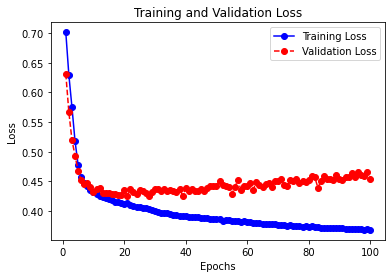

In [22]:
print("#1-9 顯示圖表來分析模型的訓練過程")
#滙入matplotlib.pyplot類別
import matplotlib.pyplot as plt       

#顯示訓練和驗證損失
#取得訓練過程中訓練資料的每一個週期損失函數值
loss = history.history["loss"]         
#設定週期範圍
epochs = range(1, len(loss)+1)         
#取得訓練過程中驗證資料的每一個週期損失函數值
val_loss = history.history["val_loss"] 
#繪出驗證資料的每一個週期損失函數值
#X座標:epochs， y座標:loss, 線的型態為bo-，圖標為Training Loss
plt.plot(epochs, loss, "bo-", label="Training Loss")
#X座標:epochs， y座標:loss, 線的型態為ro-，圖標為Validation Loss
plt.plot(epochs, val_loss, "ro--", label="Validation Loss")
plt.title("Training and Validation Loss") #設定圖片的標題
#設定圖片的X軸標題
plt.xlabel("Epochs")
#設定圖片的Y軸標題
plt.ylabel("Loss")      
#要顯示座標軸上的刻度、數字
plt.legend()           
#將圖片顯示出來 
plt.show()     

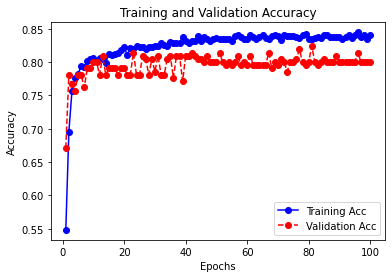

In [23]:
#顯示訓練和驗證準確度
#取得訓練過程中訓練資料的每一個週期準確率
acc = history.history["accuracy"]
#設定週期範圍    
epochs = range(1, len(acc)+1)  
#取得訓練過程中驗證資料的每一個週期準確率
val_acc = history.history["val_accuracy"]
#繪出驗證資料的每一個週期準確率
#X座標:epochs， y座標:loss, 線的型態為bo-，圖標為Training Acc
plt.plot(epochs, acc, "bo-", label="Training Acc")
#X座標:epochs， y座標:loss, 線的型態為ro-，圖標為Validation Acc
plt.plot(epochs, val_acc, "ro--", label="Validation Acc")
#設定圖片的標題
plt.title("Training and Validation Accuracy") 
#設定圖片的X軸標題
plt.xlabel("Epochs")   
#設定圖片的Y軸標題 
plt.ylabel("Accuracy") 
#要顯示座標軸上的刻度、數字
plt.legend()           
#將圖片顯示出來
plt.show()              

In [24]:
#1-10 使用全部的訓練資料集來訓練模型
#訓練模型
print("Training ...")
#X_train：訓練資料的特徵資料
#Y_train：訓練資料的輸出欄位
#validation_split：分割出驗證資料集的比例
#epochs：訓練週期
#batch_size：批次大小
#verbose：訓練過程中訊息顯示的詳細程度
#註: 沒有使用validation_split參數
model.fit(X_train, Y_train, epochs=18, batch_size=10, verbose=0) 
#評估模型
print("\nTesting ...")
#計算訓練資料集的準確度 
loss, accuracy = model.evaluate(X_train, Y_train) 
print("訓練資料集的準確度 = %.4f" % (accuracy))
#計算測試資料集的準確度 
loss, accuracy = model.evaluate(X_test, Y_test)   
print("測試資料集的準確度 = %.4f" % (accuracy))  
# 儲存Keras模型
print("Saving Model: titanic.h5 ...")
model.save("titanic.h5")

Training ...

Testing ...
33/33 [==============================] - 0s 2ms/step - loss: 0.3695 - accuracy: 0.8424
訓練資料集的準確度 = 0.8424
9/9 [==============================] - 0s 1ms/step - loss: 0.5634 - accuracy: 0.7824
測試資料集的準確度 = 0.7824
Saving Model: titanic.h5 ...


In [25]:
#1-11 載入模型、編譯模型和評估模型
# 建立Keras的Sequential模型
from tensorflow.keras.models import load_model
model = Sequential()   #建立一個序列模型
model = load_model("titanic.h5") #載入之前建立的模型

In [26]:
#編譯模型
#損失函數為binary_crossentropy
#最佳化方式採用Adam
#評估指標使用optimizer
model.compile(loss="binary_crossentropy", optimizer="adam",
              metrics=["accuracy"])

In [27]:
#評估模型
print("\nTesting ...")
loss, accuracy = model.evaluate(X_test, Y_test)
print("測試資料集的準確度 = %.4f" % (accuracy))


Testing ...
9/9 [==============================] - ETA: 1s - loss: 0.3268 - accuracy: 0.87 - 0s 2ms/step - loss: 0.5634 - accuracy: 0.7824
測試資料集的準確度 = 0.7824


In [28]:
#Y_pred = model.predict_classes(X_test) #tf2.2
#print(Y_pred[:,0])
#print(Y_test.astype(int))

Y_pred = model.predict(X_test) #new tf2.4 
for i in range(len(Y_pred)):  #new tf2.4
    if (Y_pred[i] > 0.5):   #new tf2.4
        Y_pred[i]=1        #new tf2.4
    else:                  #new tf2.4
        Y_pred[i]=0        #new tf2.4

In [29]:
#顯示混淆矩陣
#crosstab的第1個參數為列的資料，第2個參數為欄的資料, rownames為列的標籤, colnames為欄的標籤
tb = pd.crosstab(Y_test.astype(int), Y_pred[:,0],
                 rownames=["label"], colnames=["predict"])
print(tb) #顯示混淆矩陣
tb.to_html("example1_4.html")#儲存成HTML檔案

predict  0.0  1.0
label            
0        146   15
1         42   59
